In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
data=pd.read_csv("Training.csv")
print("shape:", data.shape)
print(data.head(5))

shape: (500, 1001)
   y        X1        X2        X3        X4        X5        X6        X7  \
0  1  0.276723 -0.256485  0.037465  0.790042 -1.050678  0.453624  1.278588   
1  0 -0.725315 -1.210830 -0.780793 -0.366082  0.096840 -0.384611 -0.433843   
2  0  0.038981  0.153128  0.783861  0.407169  0.718706  0.637018  0.408779   
3  1  0.367104  0.300989  0.576836  0.468976  0.249018  0.559450  1.667598   
4  0 -1.808624 -0.577878 -1.572733 -1.496252 -2.083204 -1.849994 -1.217810   

         X8        X9  ...      X991      X992      X993      X994      X995  \
0  1.613281  0.419568  ...  0.957178  0.461338  1.480470 -0.195776  1.074232   
1 -0.628685 -0.850211  ... -0.167990 -0.670412  0.577813 -0.732203 -0.792144   
2  0.199557 -0.220891  ... -0.404049  0.698210 -0.629184  0.301440  0.176711   
3 -0.233295  0.761394  ...  1.517059  0.464407 -1.034539 -0.240385 -0.163388   
4 -2.309912 -1.260882  ... -1.124031 -1.130749 -2.247910 -1.725780 -1.667178   

       X996      X997      X998

In [3]:
data.isnull().mean()

y        0.0
X1       0.0
X2       0.0
X3       0.0
X4       0.0
        ... 
X996     0.0
X997     0.0
X998     0.0
X999     0.0
X1000    0.0
Length: 1001, dtype: float64

In [4]:
print("Target:")
print(data["y"].value_counts().head(10))

Target:
y
1    251
0    249
Name: count, dtype: int64


In [5]:
from sklearn.ensemble import RandomForestClassifier
X=data.drop('y', axis=1)
Y=data['y']

rf=RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X,Y)

importances = pd.Series(rf.feature_importances_, index=X.columns)
print(importances.sort_values(ascending=False).head(30))

X9      0.024112
X8      0.017835
X7      0.013957
X19     0.003757
X320    0.003626
X876    0.003225
X528    0.003047
X900    0.002947
X76     0.002942
X388    0.002855
X681    0.002840
X301    0.002803
X661    0.002791
X958    0.002791
X748    0.002788
X785    0.002758
X190    0.002644
X386    0.002642
X945    0.002630
X523    0.002602
X601    0.002567
X51     0.002552
X630    0.002527
X606    0.002527
X48     0.002513
X993    0.002395
X547    0.002372
X12     0.002358
X577    0.002350
X261    0.002333
dtype: float64


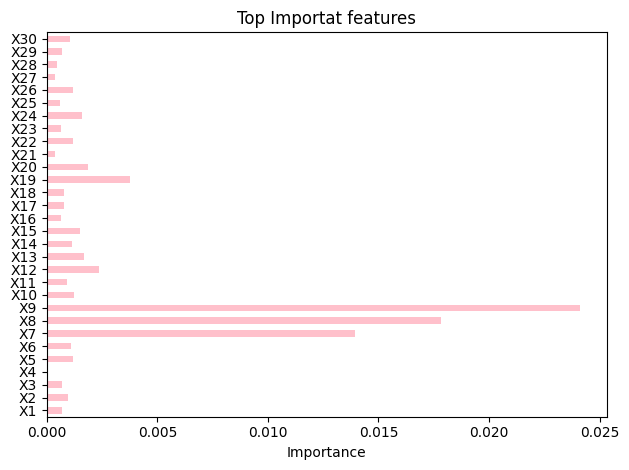

In [6]:
importances.head(30).plot(kind='barh', title='Top Importat features', color="pink")
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [7]:

from sklearn.model_selection import train_test_split 
X_train,X_test, Y_train, Y_test=train_test_split(X,Y, test_size=0.2, random_state=42)
print(f"Training:{len(X_train)} and Testing:{len(X_test)}")



Training:400 and Testing:100


In [8]:
from sklearn.linear_model import LogisticRegression #put more enphasis on weaker features+classifies in 0 and 1
from sklearn.model_selection import cross_val_score

#importance pulled (catorgorized) but still entire data 
df=['X9','X8','X7','X19','X542','X777','X872','X346','X138','X988','X502','X681','X386','X606','X851','X766','X263','X307','X468','X376']
df_X=X[df]
#L1 penalty forces weak features to zero(regressor cant tell which ones are garbage)->0.1=stronger regulation
model=LogisticRegression(penalty='l1', solver='liblinear',C=0.17, random_state=42)

#with 500 training samples with single train/test (80/20 split) uses less samples (limited base on luck)
#cross validation uses all 500 samples for both traing and testing (best for small dataset)-> split into 5-> 4 folds then test on 1 fold and repeat 5 times 
#avg the 5 accuracy scores 

cv_scores=cross_val_score(model, df_X, Y, cv=5, scoring='accuracy')
print(f'CV Accuracy:{cv_scores.mean():.5f} +/- {cv_scores.std():.5f}')

CV Accuracy:0.75800 +/- 0.05307


**Logistic Regression**

In [9]:
#L1 select from ALL 1000 features ->no prefiltering=more features 
model_full = LogisticRegression(penalty='l1', solver='liblinear', C=0.16, random_state=42)
cv_full = cross_val_score(model_full, X, Y, cv=5, scoring='accuracy')
print(f'CV Accuracy (all features L1): {cv_full.mean():.4f} +/- {cv_full.std():.4f}')

model_full.fit(X, Y)



CV Accuracy (all features L1): 0.8640 +/- 0.0320


,penalty,'l1'
,dual,False
,tol,0.0001
,C,0.16
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [10]:
#extract l1 features 
l1_f = pd.Series(model_full.coef_[0], index=X.columns)
features = l1_f[l1_f != 0].index.tolist()
print(f'Features selected: {len(features)}')

Features selected: 88


**Random Forest Classifier**

In [11]:
X_l1=X[features]
rf=RandomForestClassifier(n_estimators=250, random_state=42)
cv_rf = cross_val_score(rf, X_l1, Y, cv=5, scoring='accuracy')
print(f'RF on L1-selected features: {cv_rf.mean():.4f} +/- {cv_rf.std():.4f}')



RF on L1-selected features: 0.8080 +/- 0.0382


**SVC**

In [12]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf', random_state=42)
cv_svm = cross_val_score(svm, X_l1, Y, cv=5, scoring='accuracy')
print(f'RF on L1-selected features: {cv_svm.mean():.4f} +/- {cv_svm.std():.4f}')


RF on L1-selected features: 0.8440 +/- 0.0258


**Test Data**

In [13]:
test=pd.read_csv('test.csv')
X_kaggle=test[features]

#fit best Model= LogisticRegression
result = LogisticRegression(penalty='l1', solver='liblinear', C=0.16, random_state=42)
result.fit(X[features], Y)

preds=result.predict(X_kaggle)

#create submition file
submission = pd.DataFrame({'Id': test['Id'], 'y': preds})
submission.to_csv('submission.csv', index=False)
print(submission.head())
print(f'Submission shape: {submission.shape}')





   Id  y
0   1  0
1   2  1
2   3  1
3   4  0
4   5  0
Submission shape: (1000, 2)
